# Cloud-basiertes Multi-Algorithmus Hyperparameter-Tuning

## Vereinfachte Version für Cloud-Server (DigitalOcean, AWS, etc.)

Dieses Notebook nutzt **Python Multiprocessing** für parallele Hyperparameter-Optimierung.

**Algorithmen:**
- NSGA-II
- SMS-EMOA
- NSGA-III

**Vorteile:**
- Kein Spark/Hadoop erforderlich
- Einfaches Setup
- Nutzt alle CPU-Cores automatisch

---

## 1. Setup

In [15]:
import numpy as np
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
import warnings
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor, as_completed
warnings.filterwarnings('ignore')

# Matplotlib Style
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        pass

plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 12

print(f"Python Multiprocessing")
print(f"Available CPU cores: {mp.cpu_count()}")

Python Multiprocessing
Available CPU cores: 12


---

## 2. Konfiguration

In [16]:
# Verzeichnisse
RESULTS_DIR = Path("results")
PLOTS_DIR = Path("plots")
RESULTS_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

# Problem-Parameter
try:
    with open(RESULTS_DIR / 'config.json', 'r') as f:
        CONFIG = json.load(f)
    SEED = CONFIG['seed']
    K = CONFIG['K']
    L = CONFIG['L']
    XL = CONFIG['xl']
    XU = CONFIG['xu']
    print(f"Config loaded: K={K}, L={L}")
except FileNotFoundError:
    print("config.json not found, using defaults")
    SEED = 42
    K = 22
    L = 4
    XL = 1.0
    XU = 10.0

Config loaded: K=22, L=4


In [17]:
# ============================================================
# TUNING PARAMETER - ANPASSEN JE NACH VERFÜGBARER ZEIT
# ============================================================
# Für schnellen Test:  N_TRIALS=5, N_GEN=50, R_SIMULATIONS=500
# Für gründliche Suche: N_TRIALS=30, N_GEN=100, R_SIMULATIONS=1000

N_TRIALS = 10                # Trials pro Algorithmus (reduziert für Stabilität)
N_GEN = 60                   # Generationen pro Trial
R_SIMULATIONS = 500          # Simulationen pro Evaluation
EVAL_SEEDS = [42, 101]       # Seeds für robuste Bewertung (2 statt 3)

# Algorithmen
ALGORITHMS = ['NSGA-II', 'SMS-EMOA', 'NSGA-III']

# Hyperparameter-Suchräume
SEARCH_SPACE = {
    'pop_size': (50, 150, 20),  # Kleinere Range für schnellere Tests
    'eta_crossover': (10.0, 25.0),
    'eta_mutation': (10.0, 25.0),
    'crossover_prob': (0.8, 0.95),
    'n_partitions': (8, 12),
}

print("=" * 60)
print("HYPERPARAMETER TUNING CONFIGURATION")
print("=" * 60)
print(f"Algorithms: {ALGORITHMS}")
print(f"Trials per Algorithm: {N_TRIALS}")
print(f"Total Trials: {len(ALGORITHMS) * N_TRIALS}")
print(f"Generations: {N_GEN}")
print(f"Simulations: {R_SIMULATIONS}")
print(f"Evaluation Seeds: {EVAL_SEEDS}")
print("=" * 60)

HYPERPARAMETER TUNING CONFIGURATION
Algorithms: ['NSGA-II', 'SMS-EMOA', 'NSGA-III']
Trials per Algorithm: 10
Total Trials: 30
Generations: 60
Simulations: 500
Evaluation Seeds: [42, 101]


---

## 3. Trial-Funktion

In [18]:
def run_single_trial(params):
    """
    Führt einen einzelnen Hyperparameter-Trial aus.
    Kann parallel in verschiedenen Prozessen laufen.
    """
    import numpy as np
    import random
    import time
    
    from pymoo.algorithms.moo.nsga2 import NSGA2
    from pymoo.algorithms.moo.nsga3 import NSGA3
    from pymoo.algorithms.moo.sms import SMSEMOA
    from pymoo.operators.crossover.sbx import SBX
    from pymoo.operators.mutation.pm import PM
    from pymoo.operators.sampling.rnd import FloatRandomSampling
    from pymoo.optimize import minimize
    from pymoo.termination import get_termination
    from pymoo.indicators.hv import HV
    from pymoo.util.ref_dirs import get_reference_directions
    from simulation import TopTrumpsSimulation, TopTrumpsBalancing
    
    # Parameter extrahieren
    trial_id = params['trial_id']
    algorithm_name = params['algorithm']
    pop_size = params['pop_size']
    eta_crossover = params['eta_crossover']
    eta_mutation = params['eta_mutation']
    crossover_prob = params['crossover_prob']
    K = params['K']
    L = params['L']
    XL = params['XL']
    XU = params['XU']
    R_SIMS = params['R_SIMULATIONS']
    N_GEN = params['N_GEN']
    EVAL_SEEDS = params['EVAL_SEEDS']
    
    # Simulation erstellen
    sim = TopTrumpsSimulation(num_cards=K, num_categories=L)
    problem = TopTrumpsBalancing(sim, n_simulations=R_SIMS, xl=XL, xu=XU)
    termination = get_termination("n_gen", N_GEN)
    
    # Algorithmus erstellen
    def create_algorithm():
        if algorithm_name == 'NSGA-II':
            return NSGA2(
                pop_size=pop_size,
                sampling=FloatRandomSampling(),
                crossover=SBX(prob=crossover_prob, eta=eta_crossover),
                mutation=PM(eta=eta_mutation),
                eliminate_duplicates=True
            )
        elif algorithm_name == 'SMS-EMOA':
            return SMSEMOA(
                pop_size=pop_size,
                sampling=FloatRandomSampling(),
                crossover=SBX(prob=crossover_prob, eta=eta_crossover),
                mutation=PM(eta=eta_mutation),
                eliminate_duplicates=True
            )
        elif algorithm_name == 'NSGA-III':
            n_partitions = params.get('n_partitions', 12)
            ref_dirs = get_reference_directions("das-dennis", 2, n_partitions=n_partitions)
            return NSGA3(
                pop_size=pop_size,
                ref_dirs=ref_dirs,
                sampling=FloatRandomSampling(),
                crossover=SBX(prob=crossover_prob, eta=eta_crossover),
                mutation=PM(eta=eta_mutation),
                eliminate_duplicates=True
            )
    
    # Evaluation
    hvs = []
    start_time = time.time()
    
    for eval_seed in EVAL_SEEDS:
        np.random.seed(eval_seed)
        random.seed(eval_seed)
        
        try:
            algorithm = create_algorithm()
            res = minimize(problem, algorithm, termination, seed=eval_seed, verbose=False)
            hv = HV(ref_point=np.array([0.0, 0.0]))(res.F)
            hvs.append(hv)
        except Exception as e:
            hvs.append(float('nan'))
    
    runtime = time.time() - start_time
    
    result = {
        'trial_id': trial_id,
        'algorithm': algorithm_name,
        'pop_size': pop_size,
        'eta_crossover': eta_crossover,
        'eta_mutation': eta_mutation,
        'crossover_prob': crossover_prob,
        'hypervolume_mean': float(np.nanmean(hvs)),
        'hypervolume_std': float(np.nanstd(hvs)),
        'runtime_seconds': runtime,
        'status': 'completed' if not np.isnan(np.nanmean(hvs)) else 'failed'
    }
    
    if algorithm_name == 'NSGA-III':
        result['n_partitions'] = params.get('n_partitions')
    
    return result

---

## 4. Trial-Konfigurationen generieren

In [19]:
def generate_trial_params(algorithm, trial_id, seed):
    """Generiert zufällige Hyperparameter."""
    np.random.seed(seed)
    
    pop_min, pop_max, pop_step = SEARCH_SPACE['pop_size']
    
    params = {
        'trial_id': trial_id,
        'algorithm': algorithm,
        'pop_size': int(np.random.choice(range(pop_min, pop_max + 1, pop_step))),
        'eta_crossover': np.random.uniform(*SEARCH_SPACE['eta_crossover']),
        'eta_mutation': np.random.uniform(*SEARCH_SPACE['eta_mutation']),
        'crossover_prob': np.random.uniform(*SEARCH_SPACE['crossover_prob']),
        'K': K,
        'L': L,
        'XL': XL,
        'XU': XU,
        'R_SIMULATIONS': R_SIMULATIONS,
        'N_GEN': N_GEN,
        'EVAL_SEEDS': EVAL_SEEDS,
    }
    
    if algorithm == 'NSGA-III':
        params['n_partitions'] = int(np.random.randint(*SEARCH_SPACE['n_partitions']))
    
    return params


# Alle Trials generieren
all_trials = []
trial_id = 0

for algo in ALGORITHMS:
    for i in range(N_TRIALS):
        params = generate_trial_params(algo, trial_id, SEED + trial_id)
        all_trials.append(params)
        trial_id += 1

print(f"Generated {len(all_trials)} trial configurations")

Generated 30 trial configurations


---

## 5. Parallele Ausführung

In [20]:
# SEQUENTIELLE AUSFÜHRUNG (stabiler als Multiprocessing in Jupyter)
# Für parallele Ausführung: notebook als .py exportieren und im Terminal ausführen

print("=" * 60)
print("STARTING HYPERPARAMETER TUNING (Sequential Mode)")
print("=" * 60)
print(f"Total Trials: {len(all_trials)}")
print("Running sequentially for stability...")
print("=" * 60)

start_time = time.time()
all_results = []

for i, trial in enumerate(all_trials):
    try:
        result = run_single_trial(trial)
        all_results.append(result)
        
        # Fortschritt anzeigen
        elapsed = time.time() - start_time
        rate = (i + 1) / elapsed if elapsed > 0 else 0
        remaining = (len(all_trials) - i - 1) / rate if rate > 0 else 0
        
        status_icon = "✓" if result.get('status') == 'completed' else "✗"
        print(f"[{i+1}/{len(all_trials)}] {status_icon} {trial['algorithm']} "
              f"(HV={result.get('hypervolume_mean', 0):.4f}) - "
              f"Elapsed: {elapsed/60:.1f}min - ETA: {remaining/60:.1f}min")
              
    except Exception as e:
        print(f"[{i+1}/{len(all_trials)}] ✗ Trial failed: {e}")
        all_results.append({
            'trial_id': trial['trial_id'],
            'algorithm': trial['algorithm'],
            'status': 'failed',
            'error': str(e)
        })

total_time = time.time() - start_time

print("\n" + "=" * 60)
print("TUNING COMPLETED!")
print("=" * 60)
print(f"Total Runtime: {total_time/60:.1f} minutes")
completed_count = len([r for r in all_results if r.get('status') == 'completed'])
failed_count = len([r for r in all_results if r.get('status') == 'failed'])
print(f"Completed: {completed_count}")
print(f"Failed: {failed_count}")

STARTING HYPERPARAMETER TUNING (Sequential Mode)
Total Trials: 30
Running sequentially for stability...
[1/30] ✓ NSGA-II (HV=3.8017) - Elapsed: 2.5min - ETA: 72.9min
[2/30] ✓ NSGA-II (HV=3.9006) - Elapsed: 5.5min - ETA: 77.0min
[3/30] ✓ NSGA-II (HV=3.9559) - Elapsed: 8.4min - ETA: 75.7min
[4/30] ✓ NSGA-II (HV=3.9300) - Elapsed: 10.9min - ETA: 70.8min
[5/30] ✓ NSGA-II (HV=3.9222) - Elapsed: 26.6min - ETA: 133.2min
[6/30] ✓ NSGA-II (HV=3.2820) - Elapsed: 27.8min - ETA: 111.2min
[7/30] ✓ NSGA-II (HV=3.1935) - Elapsed: 28.9min - ETA: 95.0min
[8/30] ✓ NSGA-II (HV=3.8311) - Elapsed: 30.9min - ETA: 85.1min
[9/30] ✓ NSGA-II (HV=3.5189) - Elapsed: 32.1min - ETA: 74.8min
[10/30] ✓ NSGA-II (HV=3.6368) - Elapsed: 33.7min - ETA: 67.4min
[11/30] ✓ SMS-EMOA (HV=3.8825) - Elapsed: 37.1min - ETA: 64.1min
[12/30] ✓ SMS-EMOA (HV=3.5176) - Elapsed: 38.7min - ETA: 58.0min
[13/30] ✓ SMS-EMOA (HV=3.7787) - Elapsed: 42.1min - ETA: 55.0min
[14/30] ✓ SMS-EMOA (HV=3.7073) - Elapsed: 45.5min - ETA: 52.0min
[15/30

---

## 6. Ergebnis-Analyse

In [21]:
# DataFrame erstellen
results_df = pd.DataFrame(all_results)

# Prüfen ob Ergebnisse vorhanden sind
if len(results_df) == 0:
    print("FEHLER: Keine Ergebnisse vorhanden!")
    print("Bitte führe die vorherige Zelle (Tuning) erneut aus.")
    completed_df = pd.DataFrame()
    best_configs = {}
elif 'status' not in results_df.columns:
    print("WARNUNG: 'status' Spalte fehlt. Alle Ergebnisse werden als completed behandelt.")
    completed_df = results_df.copy()
else:
    completed_df = results_df[results_df['status'] == 'completed'].copy()

print(f"Completed Trials: {len(completed_df)}")

# Beste Konfiguration pro Algorithmus
best_configs = {}

if len(completed_df) > 0:
    print("\n" + "=" * 60)
    print("BEST CONFIGURATION PER ALGORITHM")
    print("=" * 60)

    for algo in ALGORITHMS:
        algo_df = completed_df[completed_df['algorithm'] == algo]
        if len(algo_df) > 0 and 'hypervolume_mean' in algo_df.columns:
            best_idx = algo_df['hypervolume_mean'].idxmax()
            best = algo_df.loc[best_idx].to_dict()
            best_configs[algo] = best
            
            print(f"\n{algo}:")
            print(f"  Hypervolume: {best['hypervolume_mean']:.4f} +/- {best.get('hypervolume_std', 0):.4f}")
            print(f"  pop_size: {best['pop_size']}")
            print(f"  eta_crossover: {best['eta_crossover']:.2f}")
            print(f"  eta_mutation: {best['eta_mutation']:.2f}")
            print(f"  crossover_prob: {best['crossover_prob']:.2f}")
        else:
            print(f"\n{algo}: Keine erfolgreichen Trials")
else:
    print("\nKeine erfolgreichen Trials vorhanden!")

Completed Trials: 30

BEST CONFIGURATION PER ALGORITHM

NSGA-II:
  Hypervolume: 3.9559 +/- 0.0122
  pop_size: 130
  eta_crossover: 16.49
  eta_mutation: 10.48
  crossover_prob: 0.89

SMS-EMOA:
  Hypervolume: 3.8825 +/- 0.0093
  pop_size: 150
  eta_crossover: 22.35
  eta_mutation: 12.19
  crossover_prob: 0.86

NSGA-III:
  Hypervolume: 3.6461 +/- 0.0428
  pop_size: 150
  eta_crossover: 10.47
  eta_mutation: 14.31
  crossover_prob: 0.83


In [22]:
# Algorithmus-Vergleich
print("\n" + "=" * 60)
print("ALGORITHM COMPARISON")
print("=" * 60)

comparison = []
for algo, config in best_configs.items():
    comparison.append({
        'Algorithm': algo,
        'Best HV': f"{config['hypervolume_mean']:.4f}",
        'Std': f"{config['hypervolume_std']:.4f}",
        'pop_size': config['pop_size']
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))


ALGORITHM COMPARISON
Algorithm Best HV    Std  pop_size
  NSGA-II  3.9559 0.0122       130
 SMS-EMOA  3.8825 0.0093       150
 NSGA-III  3.6461 0.0428       150


---

## 7. Visualisierung

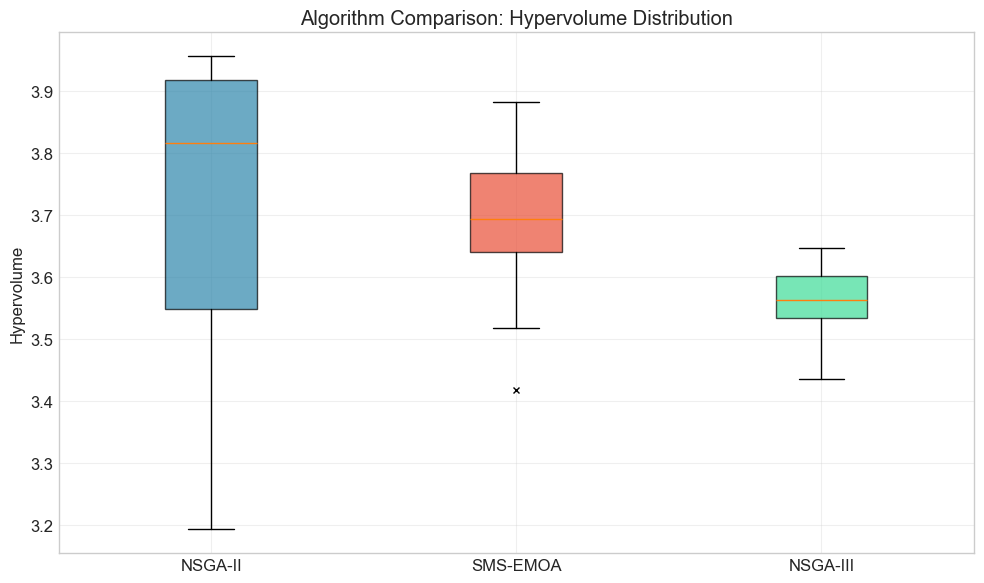

In [23]:
# Boxplot-Vergleich
if len(completed_df) > 0 and 'hypervolume_mean' in completed_df.columns:
    colors = {'NSGA-II': '#2E86AB', 'SMS-EMOA': '#E94F37', 'NSGA-III': '#3DDC97'}

    fig, ax = plt.subplots(figsize=(10, 6))

    data_for_plot = [completed_df[completed_df['algorithm'] == algo]['hypervolume_mean'].values 
                     for algo in ALGORITHMS if len(completed_df[completed_df['algorithm'] == algo]) > 0]
    labels = [algo for algo in ALGORITHMS if len(completed_df[completed_df['algorithm'] == algo]) > 0]

    if len(data_for_plot) > 0:
        bp = ax.boxplot(data_for_plot, labels=labels, patch_artist=True,
                        flierprops={'marker': 'x', 'markersize': 5})

        for patch, algo in zip(bp['boxes'], labels):
            patch.set_facecolor(colors[algo])
            patch.set_alpha(0.7)

        ax.set_ylabel('Hypervolume')
        ax.set_title('Algorithm Comparison: Hypervolume Distribution')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(PLOTS_DIR / 'cloud_tuning_comparison.png', dpi=150)
        plt.show()
    else:
        print("Keine Daten für Boxplot vorhanden")
else:
    print("Keine completed Trials für Visualisierung vorhanden")

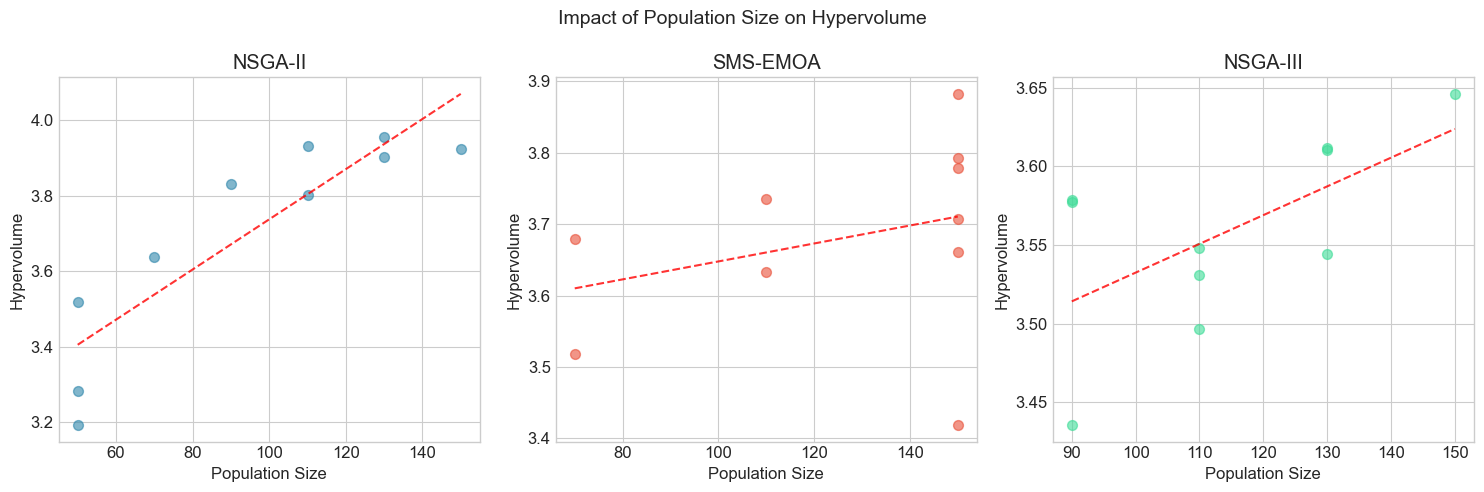

In [24]:
# pop_size Impact
if len(completed_df) > 0 and 'hypervolume_mean' in completed_df.columns and 'pop_size' in completed_df.columns:
    colors = {'NSGA-II': '#2E86AB', 'SMS-EMOA': '#E94F37', 'NSGA-III': '#3DDC97'}
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for i, algo in enumerate(ALGORITHMS):
        algo_df = completed_df[completed_df['algorithm'] == algo]
        if len(algo_df) > 0:
            axes[i].scatter(algo_df['pop_size'], algo_df['hypervolume_mean'], 
                           c=colors[algo], alpha=0.6, s=50)
            
            # Trendlinie
            if len(algo_df) > 2:
                z = np.polyfit(algo_df['pop_size'], algo_df['hypervolume_mean'], 1)
                p = np.poly1d(z)
                x_line = np.linspace(algo_df['pop_size'].min(), algo_df['pop_size'].max(), 100)
                axes[i].plot(x_line, p(x_line), 'r--', alpha=0.8)
        
        axes[i].set_xlabel('Population Size')
        axes[i].set_ylabel('Hypervolume')
        axes[i].set_title(f'{algo}')

    plt.suptitle('Impact of Population Size on Hypervolume', fontsize=14)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'cloud_tuning_popsize.png', dpi=150)
    plt.show()
else:
    print("Keine Daten für pop_size Plot vorhanden")

---

## 8. Ergebnisse speichern

In [25]:
# Alle Ergebnisse speichern
if len(all_results) > 0:
    results_export = {
        'config': {
            'K': K, 'L': L,
            'N_TRIALS': N_TRIALS,
            'N_GEN': N_GEN,
            'R_SIMULATIONS': R_SIMULATIONS,
            'ALGORITHMS': ALGORITHMS,
            'total_runtime_minutes': total_time / 60
        },
        'all_trials': all_results,
        'best_per_algorithm': {algo: {k: (float(v) if isinstance(v, (np.floating, np.integer)) else v) 
                                       for k, v in config.items()} 
                              for algo, config in best_configs.items()}
    }

    with open(RESULTS_DIR / 'cloud_tuning_results.json', 'w') as f:
        json.dump(results_export, f, indent=2, default=str)

    print(f"Results saved to: {RESULTS_DIR / 'cloud_tuning_results.json'}")
else:
    print("Keine Ergebnisse zum Speichern vorhanden")

Results saved to: results/cloud_tuning_results.json


In [26]:
# Beste Hyperparameter exportieren
if len(best_configs) > 0:
    best_params = {}

    for algo, config in best_configs.items():
        best_params[algo] = {
            'pop_size': int(config['pop_size']),
            'eta_crossover': float(config['eta_crossover']),
            'eta_mutation': float(config['eta_mutation']),
            'crossover_prob': float(config['crossover_prob']),
            'hypervolume': float(config['hypervolume_mean'])
        }

    with open(RESULTS_DIR / 'best_hyperparameters.json', 'w') as f:
        json.dump(best_params, f, indent=2)

    print(f"Best parameters saved to: {RESULTS_DIR / 'best_hyperparameters.json'}")
    print("\nContent:")
    print(json.dumps(best_params, indent=2))
else:
    print("Keine besten Hyperparameter vorhanden zum Speichern")

Best parameters saved to: results/best_hyperparameters.json

Content:
{
  "NSGA-II": {
    "pop_size": 130,
    "eta_crossover": 16.488125596731464,
    "eta_mutation": 10.476622031402641,
    "crossover_prob": 0.8941775758123034,
    "hypervolume": 3.9559480000000002
  },
  "SMS-EMOA": {
    "pop_size": 150,
    "eta_crossover": 22.35061273270674,
    "eta_mutation": 12.193802022647557,
    "crossover_prob": 0.8631026535687094,
    "hypervolume": 3.8824919999999996
  },
  "NSGA-III": {
    "pop_size": 150,
    "eta_crossover": 10.471040792538709,
    "eta_mutation": 14.306879160095551,
    "crossover_prob": 0.825896698333281,
    "hypervolume": 3.646128
  }
}


---

## 9. Zusammenfassung

### Verwendung der optimierten Parameter

```python
with open('results/best_hyperparameters.json', 'r') as f:
    best = json.load(f)

# Beispiel: NSGA-II mit optimierten Parametern
algorithm = NSGA2(
    pop_size=best['NSGA-II']['pop_size'],
    crossover=SBX(prob=best['NSGA-II']['crossover_prob'], 
                  eta=best['NSGA-II']['eta_crossover']),
    mutation=PM(eta=best['NSGA-II']['eta_mutation'])
)
```